### EDA archivos BegInvFinal12312016.csv y EndInvFinal12312016.csv

In [1]:
# Carga de librerías
import pandas as pd
import numpy as np
import matplotlib  # Para poder establecer la version que se maneja, aunque no es necesario importar
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Establecemos el estado de dependencia
! pip freeze > requirementscfdr.txt # Para actualizar mi estado de dependencia

## Se leen los archivos

In [9]:
df_BegInvFINAL = pd.read_csv (r"C:\Users\User\OneDrive - Institucion Universitaria Colegio Mayor de Antioquia\Escritorio\Proyecto_Final_Henry\PF-Inventory\BegInvFINAL12312016.csv")

In [10]:
df_EndInvFINAL = pd.read_csv (r"C:\Users\User\OneDrive - Institucion Universitaria Colegio Mayor de Antioquia\Escritorio\Proyecto_Final_Henry\PF-Inventory\EndInvFINAL12312016.csv")

In [11]:
df_BegInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01


In [12]:
df_EndInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31


## Se identifican los frames 

In [13]:
# Verificar la cantidad de registros y columnas
print(f"Registros: {df_BegInvFINAL.shape[0]}")
print(f"Columnas: {df_BegInvFINAL.shape[1]}")

Registros: 206529
Columnas: 9


In [14]:
# Verificar la cantidad de registros y columnas
print(f"Registros: {df_EndInvFINAL.shape[0]}")
print(f"Columnas: {df_EndInvFINAL.shape[1]}")

Registros: 224489
Columnas: 9


In [15]:
df_BegInvFINAL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206529 entries, 0 to 206528
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InventoryId  206529 non-null  object 
 1   Store        206529 non-null  int64  
 2   City         206529 non-null  object 
 3   Brand        206529 non-null  int64  
 4   Description  206529 non-null  object 
 5   Size         206529 non-null  object 
 6   onHand       206529 non-null  int64  
 7   Price        206529 non-null  float64
 8   startDate    206529 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 14.2+ MB


In [16]:
df_EndInvFINAL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224489 entries, 0 to 224488
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InventoryId  224489 non-null  object 
 1   Store        224489 non-null  int64  
 2   City         223205 non-null  object 
 3   Brand        224489 non-null  int64  
 4   Description  224489 non-null  object 
 5   Size         224489 non-null  object 
 6   onHand       224489 non-null  int64  
 7   Price        224489 non-null  float64
 8   endDate      224489 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 15.4+ MB


### Identificación de nulos 

In [17]:
# Vemos que columnas tienen nulos
df_BegInvFINAL.isnull().sum()[df_BegInvFINAL.isnull().sum()>0]

Series([], dtype: int64)

In [18]:
# Vemos que columnas tienen nulos
df_EndInvFINAL.isnull().sum()[df_EndInvFINAL.isnull().sum()>0]

City    1284
dtype: int64

In [19]:
#Confirmamos los nulos de cada columna
df_BegInvFINAL.isnull().sum()

InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64

### Se puede concluir que df_BegInvFINAL no tiene datos nulos 

In [20]:
#Confirmamos los nulos de cada columna
df_EndInvFINAL.isnull().sum()

InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64

### Se puede concluir que df_EndInvFinal tiene valores nulos, solo en la columna city

## Exploración de datos, para decidri que hacer con los nulos 

In [21]:
# Ver información de las columnas
for columna in df_BegInvFINAL.columns:
    print(columna)
    print(df_BegInvFINAL[columna].describe())
    print('--------------------------------')

InventoryId
count                206529
unique               206529
top       1_HARDERSFIELD_58
freq                      1
Name: InventoryId, dtype: object
--------------------------------
Store
count    206529.000000
mean         42.122457
std          23.191393
min           1.000000
25%          22.000000
50%          42.000000
75%          64.000000
max          79.000000
Name: Store, dtype: float64
--------------------------------
City
count        206529
unique           67
top       MOUNTMEND
freq          14264
Name: City, dtype: object
--------------------------------
Brand
count    206529.000000
mean      13761.482320
std       13059.429355
min          58.000000
25%        3746.000000
50%        8010.000000
75%       22143.000000
max       90090.000000
Name: Brand, dtype: float64
--------------------------------
Description
count                   206529
unique                    7291
top       Jagermeister Liqueur
freq                       459
Name: Description, dtype: ob

Buscamos determinar si cada codigo de Store corresponde a una City. Es decir si cada tienda corresponde a un punto especifico (lo que nos lleva a concluir que fisicamente no puede estar en dos ciudades al tiempo). En otras palabras es una tienda y no una cadena.

In [23]:
# Realizo un nuevo DataFrame agrupado por 'Store' y por 'City'. La finalidad es determinar si cada numero de Store le corresponde una City.
StoreAndCity=df_BegInvFINAL.groupby(['Store','City'])[['Brand']].count().reset_index()
StoreAndCity

,Store,City,Brand
0,1,HARDERSFIELD,3255
1,2,ASHBORNE,2689
2,3,HORNSEY,481
3,4,EANVERNESS,2871
4,5,SUTTON,1467
...,...,...,...
74,75,BARNCOMBE,2141
75,76,DONCASTER,5115
76,77,TAMWORTH,2465
77,78,EASTHAVEN,1225


Podemos determinar que cada Store esta ubicado en una ciudad determinada

In [24]:
# Determinado que a cada Store le corresponde una unica City, analizo cuales Store no tienen City
# Realizo un nuevo DataFrame agrupado por 'Store' y por 'City'.
df_EndInvFINAL.groupby(['Store','City'])[['Brand']].count().reset_index()

,Store,City,Brand
0,1,HARDERSFIELD,3192
1,2,ASHBORNE,2719
2,3,HORNSEY,463
3,4,EANVERNESS,2851
4,5,SUTTON,1506
...,...,...,...
74,76,DONCASTER,5120
75,77,TAMWORTH,2512
76,78,EASTHAVEN,1762
77,79,BALLYMENA,3904


Al corroborar que el codigo de Store hace referencia a una tienda y no una cadena de tiendas, buscamos determinar que tiendas tienen valores nulos en City

In [25]:
# Determino cuantos nulos de City hay agrupados por City
df_EndInvFINAL[df_EndInvFINAL['City'].isnull()].groupby('Store').size()

Store
46    1284
dtype: int64

Se puede terminar que la unica Store con City nulos es la 46

Procedemos a detirminar en que ciudad (City) esta ubicada la tienda 46. Para eso utilizamos el archivo StoreAndCity resultante del goupby de df_BegInvFINAL, el cual no tiene valores nulos.

In [26]:
# Filtrar el resultado para Store igual a 46, para determinar el nombre de la City
StoreAndCity[StoreAndCity['Store'] == 46]

,Store,City,Brand
45,46,TYWARDREATH,1880


Determinada la City vacia, hacemos el correspondiente reemplazo

In [27]:

df_EndInvFINAL.loc[(df_EndInvFINAL['Store'] == 46) & (df_EndInvFINAL['City'].isnull()), 'City'] = 'TYWARDREATH'

Verificamos que no queden nulos.

In [28]:
#Verificamos si todos siguen existiendo nulos
df_EndInvFINAL.isnull().sum()

InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
endDate        0
dtype: int64

se verifica el tipo de dato de los archivos con fecha

In [30]:
df_BegInvFINAL['startDate'].describe()

count         206529
unique             1
top       2016-01-01
freq          206529
Name: startDate, dtype: object

In [31]:
# Damos formato fecha a la columna "startDate" pero sin volvela indice.
df_BegInvFINAL['startDate'] = pd.to_datetime(df_BegInvFINAL['startDate'])

In [32]:
df_BegInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01


In [33]:
df_EndInvFINAL['endDate'].describe()

count         224489
unique             1
top       2016-12-31
freq          224489
Name: endDate, dtype: object

In [34]:
# Damos formato fecha a la columna "startDate" pero sin volvela indice.
df_EndInvFINAL['endDate'] = pd.to_datetime(df_EndInvFINAL['endDate'])

In [35]:
df_EndInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31


Verificamos que 'InventoryId' sea un identificador unico en ambos data frame.

In [36]:
df_BegInvFINAL['InventoryId'].describe()

count                206529
unique               206529
top       1_HARDERSFIELD_58
freq                      1
Name: InventoryId, dtype: object

In [37]:
df_EndInvFINAL['InventoryId'].describe()

count                224489
unique               224489
top       1_HARDERSFIELD_58
freq                      1
Name: InventoryId, dtype: object

Se puede determinar que son valores unicos

## Se analizan otras columnas para tomar explorar más datos.

In [38]:
df_BegInvFINAL['Brand'].describe()

count    206529.000000
mean      13761.482320
std       13059.429355
min          58.000000
25%        3746.000000
50%        8010.000000
75%       22143.000000
max       90090.000000
Name: Brand, dtype: float64

In [39]:
df_BegInvFINAL['Brand'].nunique()

8094

In [40]:
df_EndInvFINAL['Brand'].nunique()

9653

Se puede determinar que en el inventario inicial existe una menor variabilidad de porductos con respecto al inventario final

In [41]:
df_BegInvFINAL['Store'].nunique()

79

In [42]:
df_EndInvFINAL['Store'].nunique()

80

Vemos que en el inventario inicial solo tenemos 79 tiendas operativas miemtras que en el final 80. Procedemos a determinar cual es la tienda adicional que nos aparece en el inventario final.

In [43]:
# Obtener los valores únicos de 'Store' en cada DataFrame
stores_beg = set(df_BegInvFINAL['Store'].unique())
stores_end = set(df_EndInvFINAL['Store'].unique())

# Determinar qué 'Store' está en df_EndInvFINAL pero no en df_BegInvFINAL
stores_only_in_end = stores_end - stores_beg
print(f"Las 'Store' que están en df_EndInvFINAL pero no en df_BegInvFINAL son: {stores_only_in_end}")

# Determinar qué 'Store' está en df_BegInvFINAL pero no en df_EndInvFINAL
stores_only_in_beg = stores_beg - stores_end
print(f"Las 'Store' que están en df_BegInvFINAL pero no en df_EndInvFINAL son: {stores_only_in_beg}")

Las 'Store' que están en df_EndInvFINAL pero no en df_BegInvFINAL son: {np.int64(81)}
Las 'Store' que están en df_BegInvFINAL pero no en df_EndInvFINAL son: set()


Se puede determinar que la tienda 81 no esta en el inventario inicial pero si en el final y que todas las tiendas del inventario inicial estan dentro del inventario final. Nos indica que posiblemente se abrio una tienda nueva (o no tenia inventario al inicio) y no se cerro ninguna tienda y estan operativas con inventario

In [44]:
# Obtener los valores únicos de 'City' en cada DataFrame
cities_beg = set(df_BegInvFINAL['City'].unique())
cities_end = set(df_EndInvFINAL['City'].unique())

# Determinar qué 'City' está en df_EndInvFINAL pero no en df_BegInvFINAL
cities_only_in_end = cities_end - cities_beg
print(f"Las 'City' que están en df_EndInvFINAL pero no en df_BegInvFINAL son: {cities_only_in_end}")

# Determinar qué 'City' está en df_BegInvFINAL pero no en df_EndInvFINAL
cities_only_in_beg = cities_beg - cities_end
print(f"Las 'City' que están en df_BegInvFINAL pero no en df_EndInvFINAL son: {cities_only_in_beg}")

Las 'City' que están en df_EndInvFINAL pero no en df_BegInvFINAL son: {'PEMBROKE'}
Las 'City' que están en df_BegInvFINAL pero no en df_EndInvFINAL son: set()


Se determina que la ciudad de PEMBROKE esta operativa en el inventario final pero no en el inicial

# ETL

Creamos una nueva columna para determinar el valor del inventario (por registro), resultando de las unidades por el valor unitario.

In [45]:
# Crear la nueva columna 'TotalValue' como el producto de 'onHand' y 'Price'
df_BegInvFINAL['TotalValue'] = df_BegInvFINAL['onHand'] * df_BegInvFINAL['Price']

# Mostrar las primeras filas para verificar el resultado
df_BegInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate,TotalValue
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01,103.92
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01,76.93
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01,221.94
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01,116.97
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01,209.94


In [46]:
# Crear la nueva columna 'TotalValue' como el producto de 'onHand' y 'Price'
df_EndInvFINAL['TotalValue'] = df_EndInvFINAL['onHand'] * df_EndInvFINAL['Price']

# Mostrar las primeras filas para verificar el resultado 
df_EndInvFINAL.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate,TotalValue
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31,142.89
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31,258.93
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31,272.93
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31,139.96
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31,104.93


Calcular la sumatoria de TotalValue (Inventario total en dinero) por City para cada DataFrame y graficamos

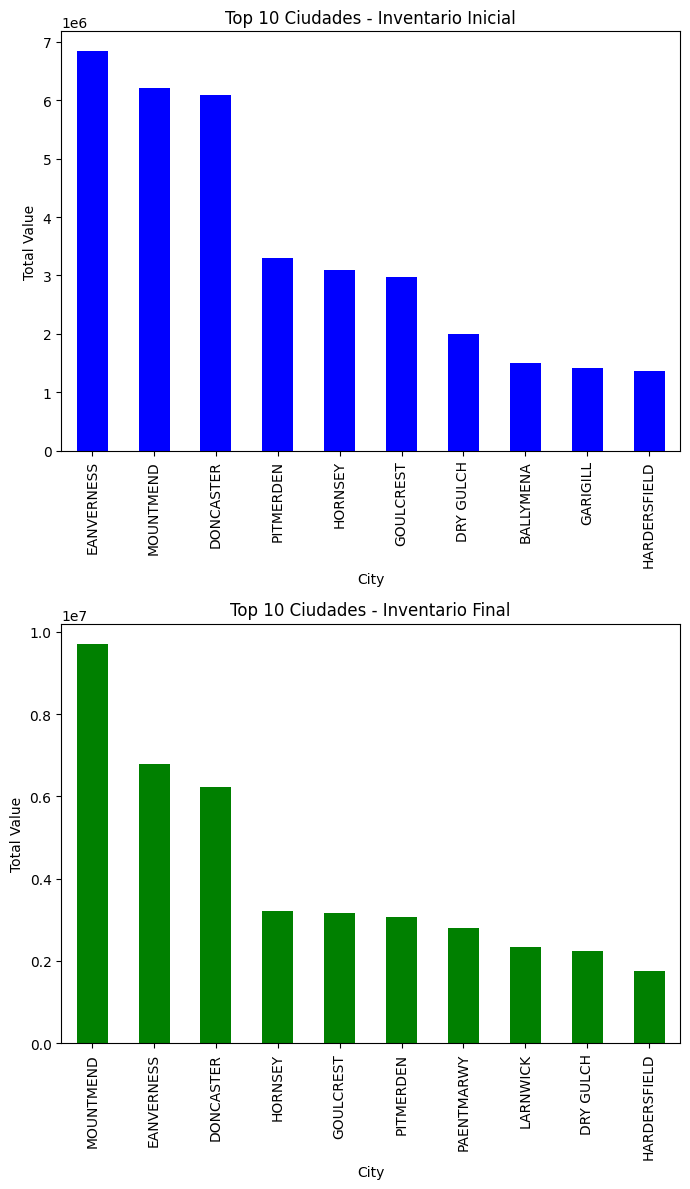

In [47]:
import matplotlib.pyplot as plt

# Agrupar por 'City' y sumar 'TotalValue' para el inventario inicial
top_cities_initial = df_BegInvFINAL.groupby('City')['TotalValue'].sum().sort_values(ascending=False).head(10)

# Agrupar por 'City' y sumar 'TotalValue' para el inventario final
top_cities_final = df_EndInvFINAL.groupby('City')['TotalValue'].sum().sort_values(ascending=False).head(10)

# Crear los gráficos de barras
fig, ax = plt.subplots(2, 1, figsize=(7,12))

# Gráfico de barras para el inventario inicial
top_cities_initial.plot(kind='bar', ax=ax[0], color='blue')
ax[0].set_title('Top 10 Ciudades - Inventario Inicial')
ax[0].set_ylabel('Total Value')
ax[0].set_xlabel('City')

# Gráfico de barras para el inventario final
top_cities_final.plot(kind='bar', ax=ax[1], color='green')
ax[1].set_title('Top 10 Ciudades - Inventario Final')
ax[1].set_ylabel('Total Value')
ax[1].set_xlabel('City')

# Mostrar los gráficos
plt.tight_layout()
plt.show()

Generamos una sola grafica en donde podemos apreciar tanto el inventario inicial como el final

<Figure size 1400x600 with 0 Axes>

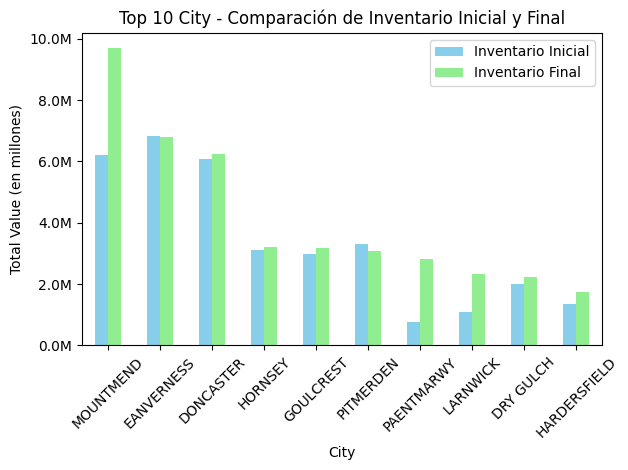

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Calcular la sumatoria de 'TotalValue' por 'City' para ambos DataFrames
total_value_initial = df_BegInvFINAL.groupby('City')['TotalValue'].sum()
total_value_final = df_EndInvFINAL.groupby('City')['TotalValue'].sum()

# Combinar ambos resultados en un solo DataFrame
combined_df = pd.DataFrame({
    'Inventario Inicial': total_value_initial,
    'Inventario Final': total_value_final
})

# Filtrar las 10 ciudades principales basadas en el 'Inventario Final'
top_cities = combined_df.nlargest(10, 'Inventario Final').sort_values(by='Inventario Final', ascending=False)

# Configuración del tamaño de la figura
plt.figure(figsize=(14, 6))

# Crear gráfica de barras agrupadas
top_cities.plot(kind='bar', color=['skyblue', 'lightgreen'])

# Formatear el eje Y para mostrar valores en millones
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Títulos y etiquetas
plt.title('Top 10 City - Comparación de Inventario Inicial y Final')
plt.ylabel('Total Value (en millones)')
plt.xlabel('City')
plt.xticks(rotation=45)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

Generamos un grafico con los productos con mayor valor de inventario

<Figure size 1000x600 with 0 Axes>

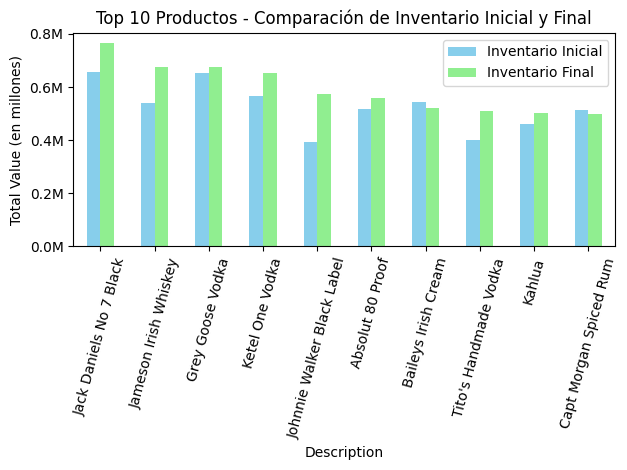

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Calcular la sumatoria de 'TotalValue' por 'Description' para ambos DataFrames
total_value_initial = df_BegInvFINAL.groupby('Description')['TotalValue'].sum()
total_value_final = df_EndInvFINAL.groupby('Description')['TotalValue'].sum()

# Combinar ambos resultados en un solo DataFrame
combined_df = pd.DataFrame({
    'Inventario Inicial': total_value_initial,
    'Inventario Final': total_value_final
})

# Filtrar las 10 principales marcas basadas en el 'Inventario Final'
top_Description = combined_df.nlargest(10, 'Inventario Final').sort_values(by='Inventario Final', ascending=False)

# Configuración del tamaño de la figura
plt.figure(figsize=(10, 6))

# Crear gráfica de barras agrupadas
top_Description.plot(kind='bar', color=['skyblue', 'lightgreen'])

# Formatear el eje Y para mostrar valores en millones
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Títulos y etiquetas
plt.title('Top 10 Productos - Comparación de Inventario Inicial y Final')
plt.ylabel('Total Value (en millones)')
plt.xlabel('Description')
plt.xticks(rotation=75)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

Unificamos los nombre con el resto de las tablas

In [50]:
# Renombrar columnas en df_BegInvFINAL (Inventario Inicial)
df_BegInvFINAL.rename(columns={
    'InventoryId': 'Inventario_inicialID',
    'Store': 'Tienda',
    'City': 'Ciudad',
    'Brand': 'MarcaID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'onHand': 'Unidad_disponible',
    'Price': 'Precio_venta',
    'startDate': 'Fecha',
    'TotalValue': 'Valor_total'
}, inplace=True)

# Renombrar columnas en df_EndInvFINAL (Inventario Final)
df_EndInvFINAL.rename(columns={
    'InventoryId': 'Inventario_finalID',
    'Store': 'Tienda',
    'City': 'Ciudad',
    'Brand': 'MarcaID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'onHand': 'Unidad_disponible',
    'Price': 'Precio_venta',
    'endDate': 'Fecha',
    'TotalValue': 'Valor_total'
}, inplace=True)

Verificamos los cambios

In [51]:
df_BegInvFINAL.head()

,Inventario_inicialID,Tienda,Ciudad,MarcaID,Descripcion,Tamaño,Unidad_disponible,Precio_venta,Fecha,Valor_total
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01,103.92
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01,76.93
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01,221.94
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01,116.97
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01,209.94


In [52]:
df_EndInvFINAL.head()

,Inventario_finalID,Tienda,Ciudad,MarcaID,Descripcion,Tamaño,Unidad_disponible,Precio_venta,Fecha,Valor_total
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2016-12-31,142.89
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2016-12-31,258.93
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2016-12-31,272.93
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2016-12-31,139.96
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2016-12-31,104.93


In [56]:
# Guardamos los datos de acuerdo a las especificaciones realizadas
df_BegInvFINAL.to_csv("Inventario_Inicial_Clean1.csv", index=False)

In [57]:
df_EndInvFINAL.to_csv("Inventario_Final_Clean1.csv", index=False)